# Regression models

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Loading and preparing the dataset

In [2]:
df = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## 2. exploratory data analysis

In [4]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [5]:
df.describe(include=['str']).T

,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


## 3. data preparation

In [6]:
df['MSSubClass'] = df['MSSubClass'].astype(str)

df.dtypes.value_counts()

str        44
int64      34
float64     3
Name: count, dtype: int64

In [7]:
missing = df.isna().sum()[lambda s: s > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({
    'n_missing': missing,
    'pct_missing': missing_pct,
})
missing_table

,n_missing,pct_missing
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


Skewness: 1.883
Kurtosis: 6.536


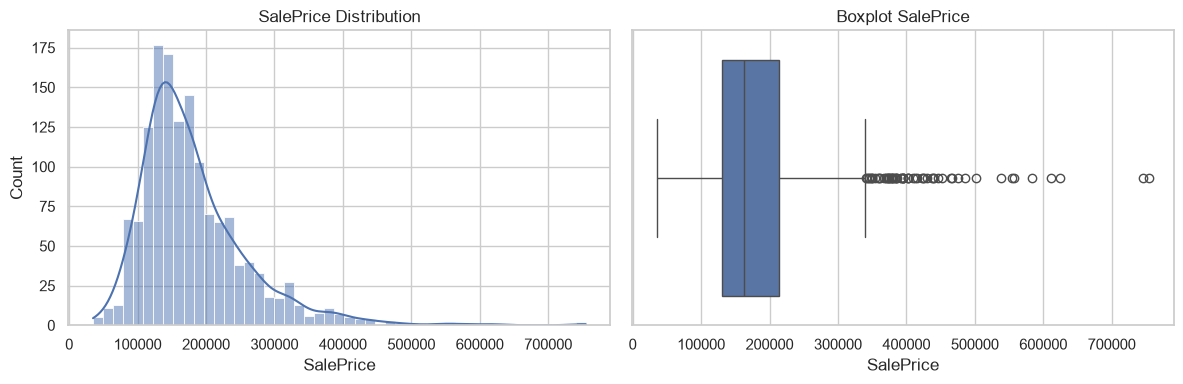

In [8]:
display(df['SalePrice'].describe().to_frame())
print(f"Skewness: {df['SalePrice'].skew():.3f}")
print(f"Kurtosis: {df['SalePrice'].kurtosis():.3f}")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title(f'SalePrice Distribution')
sns.boxplot(x=df['SalePrice'], ax=axes[1])
axes[1].set_title(f'Boxplot SalePrice')
plt.tight_layout()
plt.show()


Top 15 numerical features by strength of correlation with SalePrice:


,corr_with_SalePrice
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


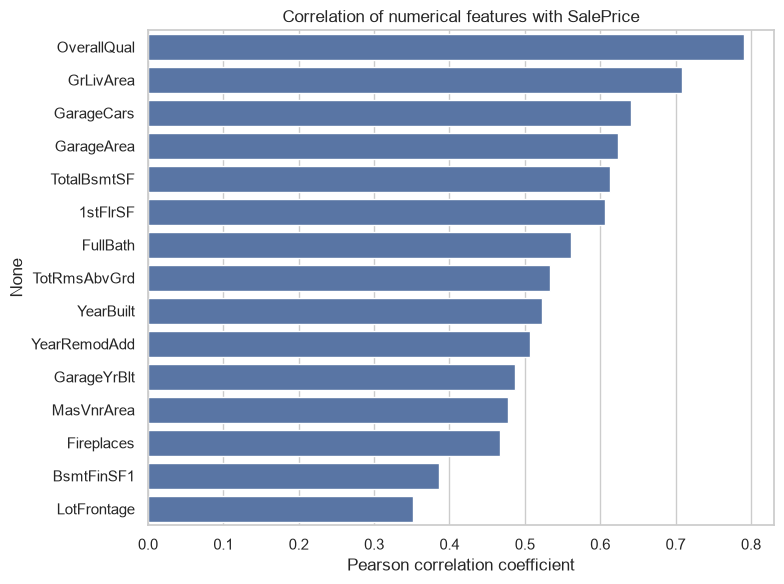

In [9]:
numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()

corr_with_target = df[numeric_cols_all].corr()['SalePrice'].drop('SalePrice').sort_values(key=abs, ascending=False)
print("Top 15 numerical features by strength of correlation with SalePrice:")
top_corr = corr_with_target.head(15)
display(top_corr.to_frame('corr_with_SalePrice'))

plt.figure(figsize=(8, 6))
sns.barplot(x=top_corr.values, y=top_corr.index, orient='h')
plt.title('Correlation of numerical features with SalePrice')
plt.xlabel('Pearson correlation coefficient')
plt.tight_layout()
plt.show()

## 4. Feature matrix X and target vector y

In [10]:
TARGET = 'SalePrice'

X = df.drop(columns=[TARGET, 'Id']).copy()
y = df[TARGET].copy()

In [11]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=[str]).columns.tolist()

## 5. Splitting into train, validation, and test sets

In [12]:
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=RANDOM_STATE)

print(f"X_train: {X_train.shape} ({len(X_train)/len(X):.0%})")
print(f"X_val:   {X_val.shape} ({len(X_val)/len(X):.0%})")
print(f"X_test:  {X_test.shape} ({len(X_test)/len(X):.0%})")

X_train: (876, 79) (60%)
X_val:   (292, 79) (20%)
X_test:  (292, 79) (20%)


## 6. Handling missing values, encoding, and feature scaling

In [13]:
missing_train = X_train.isna().sum()
missing_train[lambda s: s > 0].sort_values(ascending=False)

PoolQC          870
MiscFeature     840
Alley           819
Fence           698
MasVnrType      504
FireplaceQu     401
LotFrontage     163
GarageType       49
GarageYrBlt      49
GarageFinish     49
GarageQual       49
GarageCond       49
BsmtCond         23
BsmtFinType1     23
BsmtExposure     23
BsmtQual         23
BsmtFinType2     23
MasVnrArea        5
Electrical        1
dtype: int64

In [14]:
none_means_absence = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 
       'GarageType', 'GarageCond', 'GarageFinish', 'GarageQual', 'BsmtFinType2', 
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1']


def build_preprocessor(X_fit_raw):
    Xf = X_fit_raw.copy()
    for col in none_means_absence:
       Xf[col] = Xf[col].fillna('None')
    
    cat_cols = Xf.select_dtypes(include=[str]).columns.tolist()
    num_cols = Xf.select_dtypes(include=[np.number]).columns.tolist()

    remaining_cat = [c for c in cat_cols if Xf[c].isna().any()]
    remaining_num = [c for c in num_cols if Xf[c].isna().any()]

    cat_imputer = SimpleImputer(strategy='most_frequent')
    if remaining_cat:
        cat_imputer.fit(Xf[remaining_cat])
        Xf[remaining_cat] = cat_imputer.transform(Xf[remaining_cat])

    num_imputer = SimpleImputer(strategy='median')
    if remaining_num:
        num_imputer.fit(Xf[remaining_num])
        Xf[remaining_num] = num_imputer.transform(Xf[remaining_num])

    iqr_bounds = {}
    for c in num_cols:
        q1, q3 = Xf[c].quantile(0.25), Xf[c].quantile(0.75)
        iqr = q3 - q1
        iqr_bounds[c] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)
        Xf[c] = Xf[c].clip(lower=iqr_bounds[c][0], upper=iqr_bounds[c][1])

        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        ohe.fit(Xf[cat_cols])

        scaler = StandardScaler()
        scaler.fit(Xf[num_cols])


    return dict(cat_cols=cat_cols, num_cols=num_cols, 
                remaining_cat=remaining_cat, remaining_num=remaining_num, 
                cat_imputer=cat_imputer, num_imputer=num_imputer,
                iqr_bounds=iqr_bounds, ohe=ohe, scaler=scaler)


def apply_preprocessor(X_raw, prep):
    Xr = X_raw.copy()
    for col in none_means_absence:
        Xr[col] = Xr[col].fillna('None')

    if prep['remaining_cat']:
        Xr[prep['remaining_cat']] = prep['cat_imputer'].transform(Xr[prep['remaining_cat']])
    if prep['remaining_num']:
        Xr[prep['remaining_num']] = prep['num_imputer'].transform(Xr[prep['remaining_num']])

    for c in prep['num_cols']:
        lo, hi = prep['iqr_bounds'][c]
        Xr[c] = Xr[c].clip(lower=lo, upper=hi)

    X_cat = pd.DataFrame(
        prep['ohe'].transform(Xr[prep['cat_cols']]),
        columns=prep['ohe'].get_feature_names_out(prep['cat_cols']),
        index=Xr.index
    )
    X_num = pd.DataFrame(
        prep['scaler'].transform(Xr[prep['num_cols']]),
        columns=prep['num_cols'],
        index=Xr.index
    )
    
    return pd.concat([X_num, X_cat], axis=1)

In [15]:
prep = build_preprocessor(X_train)

X_train_final = apply_preprocessor(X_train, prep)
X_val_final = apply_preprocessor(X_val, prep)
X_test_final = apply_preprocessor(X_test, prep)

y_train_final = y_train.reset_index(drop=True)
y_val_final = y_val.reset_index(drop=True)
y_test_final = y_test.reset_index(drop=True)
X_train_final = X_train_final.reset_index(drop=True)
X_val_final = X_val_final.reset_index(drop=True)
X_test_final = X_test_final.reset_index(drop=True)

print(f"X_train_final: {X_train_final.shape}")
print(f"X_val_final:   {X_val_final.shape}")
print(f"X_test_final:  {X_test_final.shape}")

X_train_final: (876, 310)
X_val_final:   (292, 310)
X_test_final:  (292, 310)


In [16]:
print('Numerical features before scaling (train), mean / std:')
display(X_train[prep['num_cols']].agg(['mean', 'std']).T.head())

print('After standardization (train), mean / std:')
display(X_train_final[prep['num_cols']].agg(['mean', 'std']).T.head())

Numerical features before scaling (train), mean / std:


,mean,std
LotFrontage,70.276297,25.662639
LotArea,10880.632420,11939.408382
OverallQual,6.110731,1.380790
OverallCond,5.597032,1.132760
YearBuilt,1970.331050,30.876972


After standardization (train), mean / std:


,mean,std
LotFrontage,-1.135571e-16,1.000571
LotArea,2.027805e-17,1.000571
OverallQual,-2.311697e-16,1.000571
OverallCond,1.419463e-16,1.000571
YearBuilt,1.017958e-15,1.000571


## 7. Linear Regression

In [17]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

In [18]:
lr = LinearRegression()
lr.fit(X_train_final, y_train_final)

y_train_pred_lr = lr.predict(X_train_final)
y_val_pred_lr = lr.predict(X_val_final)

lr_train_metrics = regression_metrics(y_train_final, y_train_pred_lr)
lr_val_metrics = regression_metrics(y_val_final, y_val_pred_lr)

print('Linear Regression metrics:')
lr_metrics_table = pd.DataFrame({'train': lr_train_metrics, 'validation': lr_val_metrics}).T
lr_metrics_table

Linear Regression metrics:


,MAE,MSE,RMSE,R2
train,12193.623742,3.363774e+08,18340.594103,0.943527
validation,18864.458575,8.177026e+08,28595.499901,0.863453


## 8. Ridge Regression

In [19]:
ridge_alphas = [0.01, 0.1, 1, 5, 10, 50, 100, 500, 1000, 5000, 10000]

ridge_results = []
ridge_models = {}
for a in ridge_alphas:
    model = Ridge(alpha=a, random_state=RANDOM_STATE)
    model.fit(X_train_final, y_train_final)
    ridge_models[a] = model
    y_val_pred = model.predict(X_val_final)
    m = regression_metrics(y_val_final, y_val_pred)
    m['alpha'] = a
    ridge_results.append(m)

ridge_results_df = pd.DataFrame(ridge_results)[['alpha', 'MAE', 'MSE', 'RMSE', 'R2']]
ridge_results_df

,alpha,MAE,MSE,RMSE,R2
0,0.01,18837.305311,8.151154e+08,28550.226522,0.863885
1,0.10,18681.607269,7.989968e+08,28266.531504,0.866576
2,1.00,18284.605897,7.464363e+08,27320.985773,0.875353
3,5.00,17281.905753,6.934832e+08,26334.069058,0.884196
4,10.00,16812.617320,6.775408e+08,26029.614299,0.886858
5,50.00,16278.738515,6.975903e+08,26411.934500,0.883510
6,100.00,16712.592420,7.410757e+08,27222.706179,0.876249
7,500.00,19008.438852,9.521223e+08,30856.479300,0.841006
8,1000.00,20471.061584,1.118516e+09,33444.221556,0.813220
9,5000.00,29584.509975,2.052560e+09,45305.188709,0.657245


In [20]:
best_ridge_alpha = ridge_results_df.loc[ridge_results_df['RMSE'].idxmin(), 'alpha']
ridge_best = ridge_models[best_ridge_alpha]

print('Best ridge alpha:', best_ridge_alpha)

Best ridge alpha: 10.0


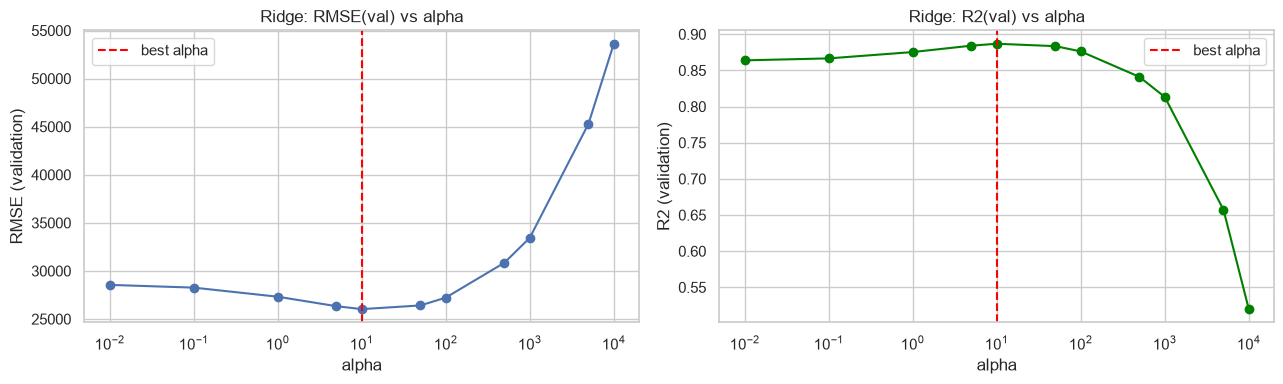

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ridge_results_df['alpha'], ridge_results_df['RMSE'], marker='o')
axes[0].set_xscale('log')
axes[0].axvline(best_ridge_alpha, color='red', linestyle='--', label='best alpha')
axes[0].set_xlabel('alpha')
axes[0].set_ylabel('RMSE (validation)')
axes[0].set_title('Ridge: RMSE(val) vs alpha')
axes[0].legend()

axes[1].plot(ridge_results_df['alpha'], ridge_results_df['R2'], marker='o', color='green')
axes[1].set_xscale('log')
axes[1].axvline(best_ridge_alpha, color='red', linestyle='--', label='best alpha')
axes[1].set_xlabel('alpha')
axes[1].set_ylabel('R2 (validation)')
axes[1].set_title('Ridge: R2(val) vs alpha')
axes[1].legend()
plt.tight_layout()

## 9. Lasso Regression

In [22]:
lasso_alphas = [0.01, 0.1, 1, 5, 10, 50, 100, 500, 1000, 5000, 10000]

lasso_results = []
lasso_models = {}
for a in lasso_alphas:
    model = Lasso(alpha=a, random_state=RANDOM_STATE, max_iter=50000)
    model.fit(X_train_final, y_train_final)
    lasso_models[a] = model
    y_val_pred = model.predict(X_val_final)
    m = regression_metrics(y_val_final, y_val_pred)
    m['alpha'] = a
    m['n_nonzero_coef'] = int(np.sum(model.coef_ != 0))
    lasso_results.append(m)

lasso_results_df = pd.DataFrame(lasso_results)[['alpha', 'MAE', 'MSE', 'RMSE', 'R2', 'n_nonzero_coef']]
lasso_results_df

/home/psa/anaconda3/envs/Machine-Learning-Technologies/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.296693e+10, tolerance: 5.218e+08
  model = cd_fast.enet_coordinate_descent(
/home/psa/anaconda3/envs/Machine-Learning-Technologies/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.277779e+10, tolerance: 5.218e+08
  model = cd_fast.enet_coordinate_descent(


,alpha,MAE,MSE,RMSE,R2,n_nonzero_coef
0,0.01,18685.276571,7.997548e+08,28279.935501,0.866450,278
1,0.10,18654.836297,7.977541e+08,28244.541697,0.866784,274
2,1.00,18535.177192,7.868018e+08,28049.987855,0.868613,267
3,5.00,18127.632931,7.488684e+08,27365.460158,0.874947,225
4,10.00,17781.344547,7.193917e+08,26821.478085,0.879870,220
5,50.00,16489.718705,6.397675e+08,25293.626551,0.893166,154
6,100.00,16230.803965,6.332388e+08,25164.236359,0.894256,107
7,500.00,16731.370557,7.466374e+08,27324.666836,0.875320,50
8,1000.00,18207.587588,8.739588e+08,29562.793618,0.854059,29
9,5000.00,21202.898039,1.122339e+09,33501.325509,0.812582,13


In [23]:
best_lasso_alpha = lasso_results_df.loc[lasso_results_df['RMSE'].idxmin(), 'alpha']
lasso_best = lasso_models[best_lasso_alpha]
n_zero = int(np.sum(lasso_best.coef_ == 0))

print('Best lasso alpha:', best_lasso_alpha)
print(f"Number of coefficients zeroed out at alpha={best_lasso_alpha}: {n_zero} out of {len(lasso_best.coef_)}")

Best lasso alpha: 100.0
Number of coefficients zeroed out at alpha=100.0: 203 out of 310


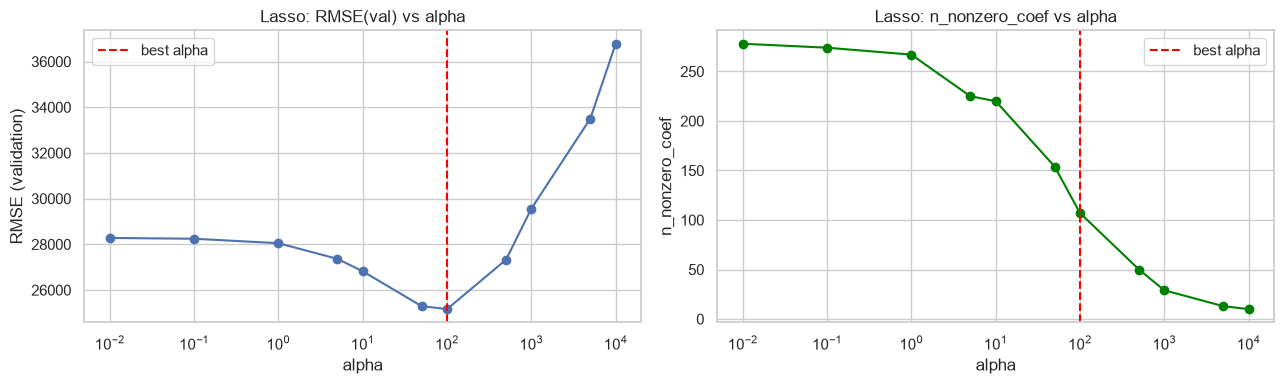

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(lasso_results_df['alpha'], lasso_results_df['RMSE'], marker='o')
axes[0].set_xscale('log')
axes[0].axvline(best_lasso_alpha, color='red', linestyle='--', label='best alpha')
axes[0].set_xlabel('alpha')
axes[0].set_ylabel('RMSE (validation)')
axes[0].set_title('Lasso: RMSE(val) vs alpha')
axes[0].legend()

axes[1].plot(lasso_results_df['alpha'], lasso_results_df['n_nonzero_coef'], marker='o', color='green')
axes[1].set_xscale('log')
axes[1].axvline(best_lasso_alpha, color='red', linestyle='--', label='best alpha')
axes[1].set_xlabel('alpha')
axes[1].set_ylabel('n_nonzero_coef')
axes[1].set_title('Lasso: n_nonzero_coef vs alpha')
axes[1].legend()
plt.tight_layout()

## 10. The best model and final evaluation on the test set

In [25]:
candidates = {
    'Linear Regression': (lr_val_metrics['RMSE'], None),
    f'Ridge (alpha={best_ridge_alpha})' : (
        ridge_results_df.loc[ridge_results_df['alpha'] == best_ridge_alpha, 'RMSE'].iloc[0], best_ridge_alpha
    ),
    f'Lasso (alpha={best_lasso_alpha})' : (
        lasso_results_df.loc[lasso_results_df['alpha'] == best_lasso_alpha, 'RMSE'].iloc[0], best_lasso_alpha
    ),
}

for name, (rmse, alpha) in candidates.items():
    print(f"{name}: RMSE={rmse:,.2f}")

best_name = min(candidates, key=lambda k: candidates[k][0])
print(f"\nSelected model for final evaluation: {best_name}")

Linear Regression: RMSE=28,595.50
Ridge (alpha=10.0): RMSE=26,029.61
Lasso (alpha=100.0): RMSE=25,164.24

Selected model for final evaluation: Lasso (alpha=100.0)


In [26]:
X_trainval_raw = pd.concat([X_train, X_val], axis=0)
y_trainval_final = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

prep_final = build_preprocessor(X_trainval_raw)
X_trainval_final = apply_preprocessor(X_trainval_raw, prep_final).reset_index(drop=True)
X_test_final_2 = apply_preprocessor(X_test, prep_final).reset_index(drop=True)

final_model = Lasso(alpha=best_lasso_alpha, random_state=RANDOM_STATE, max_iter=50000)
final_model.fit(X_trainval_final, y_trainval_final)

y_test_pred_final = final_model.predict(X_test_final_2)
final_test_metrics = regression_metrics(y_test_final, y_test_pred_final)

pd.Series(final_test_metrics).to_frame('test')

,test
MAE,1.729601e+04
MSE,8.102403e+08
RMSE,2.846472e+04
R2,8.943669e-01


## 11. Analysis of model coefficients

In [27]:
feature_names = X_train_final.columns.tolist()

coef_df = pd.DataFrame({
    'feature': feature_names,
    'LinearRegression': lr.coef_,
    f'Ridge(alpha={best_ridge_alpha})': ridge_best.coef_,
    f'Lasso(alpha={best_lasso_alpha})': lasso_best.coef_,
})

summary = pd.DataFrame({
    'sum_abs_coef': coef_df.drop(columns='feature').abs().sum(),
    'mean_abs_coef': coef_df.drop(columns='feature').abs().mean(),
    'max_abs_coef': coef_df.drop(columns='feature').abs().max(),
    'n_zero_coef': (coef_df.drop(columns='feature') == 0).sum(),
})
summary

,sum_abs_coef,mean_abs_coef,max_abs_coef,n_zero_coef
LinearRegression,4.097124e+06,13216.527444,298364.794040,0
Ridge(alpha=10.0),1.069626e+06,3450.405383,23195.333061,9
Lasso(alpha=100.0),1.011938e+06,3264.316486,200207.985819,203


In [28]:
print(f"Total number of features: {len(feature_names)}")
print(f"Zeroed out by Lasso (alpha={best_lasso_alpha}): "
f"{(coef_df[f'Lasso(alpha={best_lasso_alpha})'] == 0).sum()}")
print(f"Zeroed out by Ridge: {(coef_df[f'Ridge(alpha={best_ridge_alpha})'] == 0).sum()} (Ridge shrinks coefficients to small values rather than zeroing them)")

Total number of features: 310
Zeroed out by Lasso (alpha=100.0): 203
Zeroed out by Ridge: 9 (Ridge shrinks coefficients to small values rather than zeroing them)


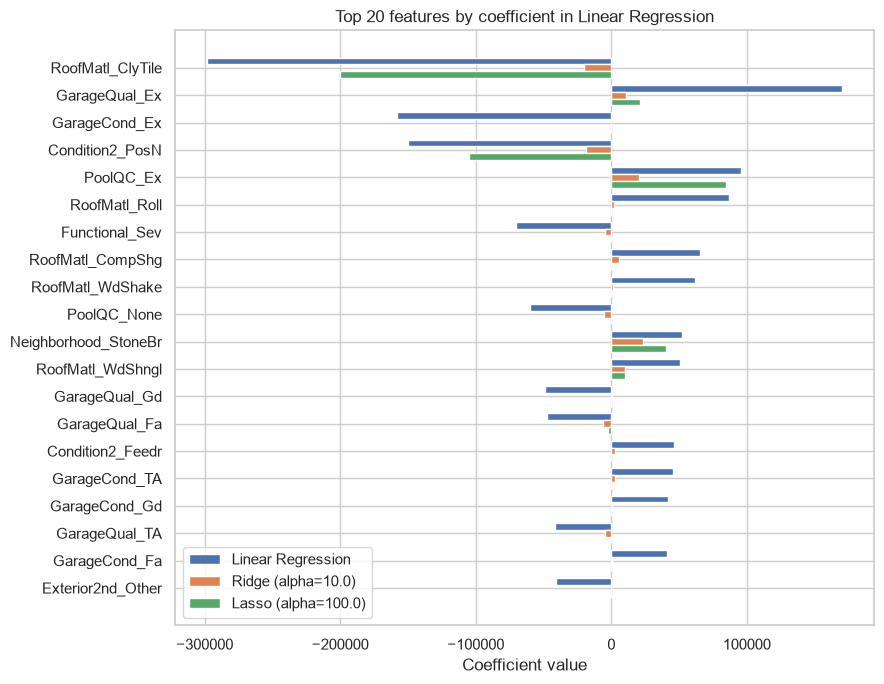

In [29]:
top_n = 20
top_by_lr = coef_df.reindex(coef_df['LinearRegression'].abs().sort_values(ascending=False).index).head(top_n)

plt.figure(figsize=(9, 7))
y_pos = np.arange(top_n)
width = 0.25
plt.barh(y_pos - width, top_by_lr['LinearRegression'], height=width, label='Linear Regression')
plt.barh(y_pos, top_by_lr[f'Ridge(alpha={best_ridge_alpha})'], height=width, label=f'Ridge (alpha={best_ridge_alpha})')
plt.barh(y_pos + width, top_by_lr[f'Lasso(alpha={best_lasso_alpha})'], height=width, label=f'Lasso (alpha={best_lasso_alpha})')
plt.yticks(y_pos, top_by_lr['feature'])
plt.gca().invert_yaxis()
plt.xlabel('Coefficient value')
plt.title(f'Top {top_n} features by coefficient in Linear Regression')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
top_lasso_nonzero = coef_df[coef_df[f'Lasso(alpha={best_lasso_alpha})'] != 0].copy()
top_lasso_nonzero['abs_coef'] = top_lasso_nonzero[f'Lasso(alpha={best_lasso_alpha})'].abs()
top_lasso_nonzero = top_lasso_nonzero.sort_values('abs_coef', ascending=False).head(15)

top_lasso_nonzero[['feature', f'Lasso(alpha={best_lasso_alpha})']]

,feature,Lasso(alpha=100.0)
137,RoofMatl_ClyTile,-200207.985819
114,Condition2_PosN,-104904.175107
281,PoolQC_Ex,84821.214184
99,Neighborhood_StoneBr,40305.513124
92,Neighborhood_NoRidge,34667.840826
238,KitchenQual_Ex,25529.861071
93,Neighborhood_NridgHt,24933.382851
12,2ndFlrSF,23280.201542
266,GarageQual_Ex,21115.077737
146,Exterior1st_BrkFace,20096.417986


## 12. Results for the three models

In [31]:
ridge_val_best_metrics = ridge_results_df.set_index('alpha').loc[best_ridge_alpha, ['MAE', 'MSE', 'RMSE', 'R2']].to_dict()
lasso_val_best_metrics = lasso_results_df.set_index('alpha').loc[best_lasso_alpha, ['MAE', 'MSE', 'RMSE', 'R2']].to_dict()

y_train_pred_ridge = ridge_best.predict(X_train_final)
ridge_train_metrics = regression_metrics(y_train_final, y_train_pred_ridge)

y_train_pred_lasso = lasso_best.predict(X_train_final)
lasso_train_metrics = regression_metrics(y_train_final, y_train_pred_lasso)

comparison_table = pd.DataFrame({
    ('LinearRegression', 'train'): lr_train_metrics,
    ('LinearRegression', 'validation'): lr_val_metrics,
    (f'Ridge (alpha={best_ridge_alpha})', 'train'): ridge_train_metrics,
    (f'Ridge (alpha={best_ridge_alpha})', 'validation'): ridge_val_best_metrics,
    (f'Lasso (alpha={best_lasso_alpha})', 'train'): lasso_train_metrics,
    (f'Lasso (alpha={best_lasso_alpha})', 'validation'): lasso_val_best_metrics,
}).T

comparison_table

MAE           MSE          RMSE  \
LinearRegression    train       12193.623742  3.363774e+08  18340.594103   
                    validation  18864.458575  8.177026e+08  28595.499901   
Ridge (alpha=10.0)  train       13834.188780  5.295321e+08  23011.564539   
                    validation  16812.617320  6.775408e+08  26029.614299   
Lasso (alpha=100.0) train       13736.871754  4.494833e+08  21201.021872   
                    validation  16230.803965  6.332388e+08  25164.236359   

                                      R2  
LinearRegression    train       0.943527  
                    validation  0.863453  
Ridge (alpha=10.0)  train       0.911099  
                    validation  0.886858  
Lasso (alpha=100.0) train       0.924538  
                    validation  0.894256

## 13. Graphical representation of the results

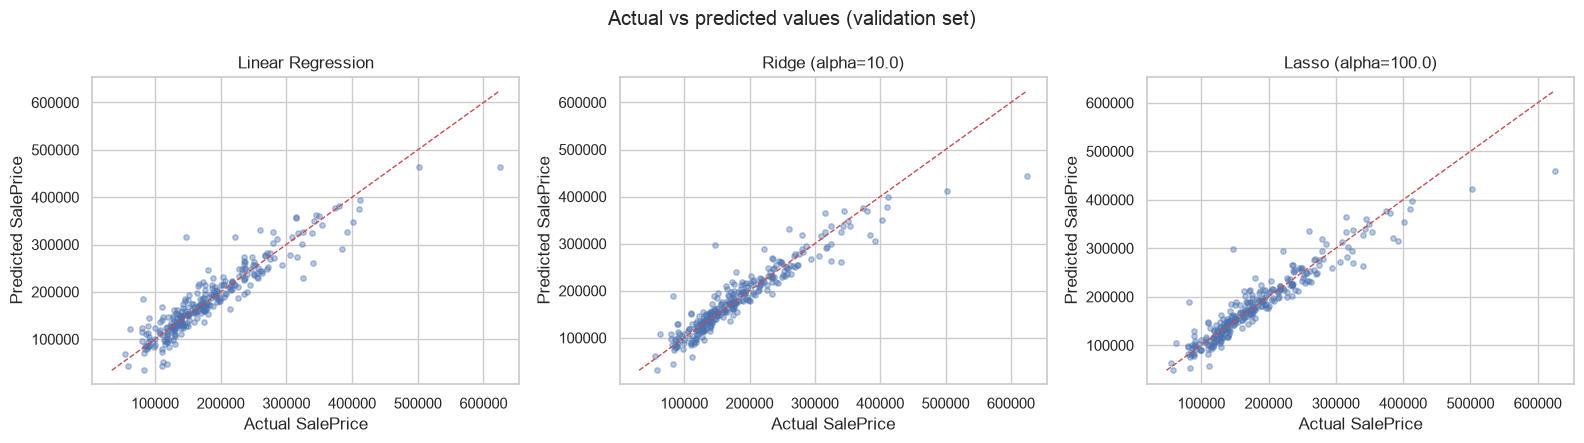

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
models_preds = {
    'Linear Regression': y_val_pred_lr,
    f'Ridge (alpha={best_ridge_alpha})': ridge_best.predict(X_val_final),
    f'Lasso (alpha={best_lasso_alpha})': lasso_best.predict(X_val_final),
}
for ax, (name, preds) in zip(axes, models_preds.items()):
    ax.scatter(y_val_final, preds, alpha=0.4, s=15)
    lims = [min(y_val_final.min(), preds.min()), max(y_val_final.max(), preds.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel('Actual SalePrice')
    ax.set_ylabel('Predicted SalePrice')
    ax.set_title(name)
plt.suptitle('Actual vs predicted values (validation set)')
plt.tight_layout()
plt.show()

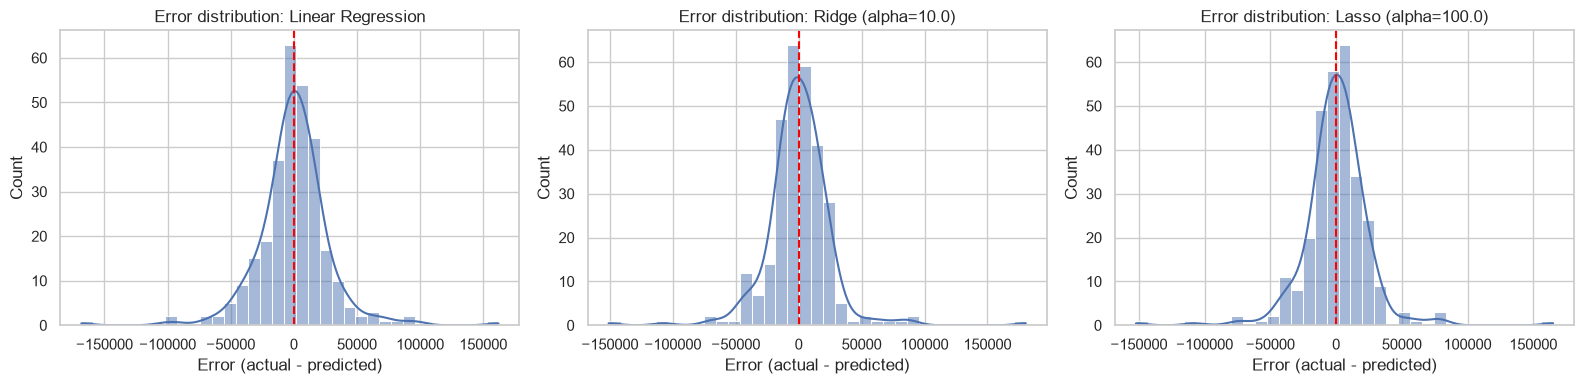

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, preds) in zip(axes, models_preds.items()):
    errors = y_val_final - preds
    sns.histplot(errors, kde=True, ax=ax)
    ax.axvline(0, color='red', linestyle='--')
    ax.set_title(f'Error distribution: {name}')
    ax.set_xlabel('Error (actual - predicted)')
plt.tight_layout()
plt.show()

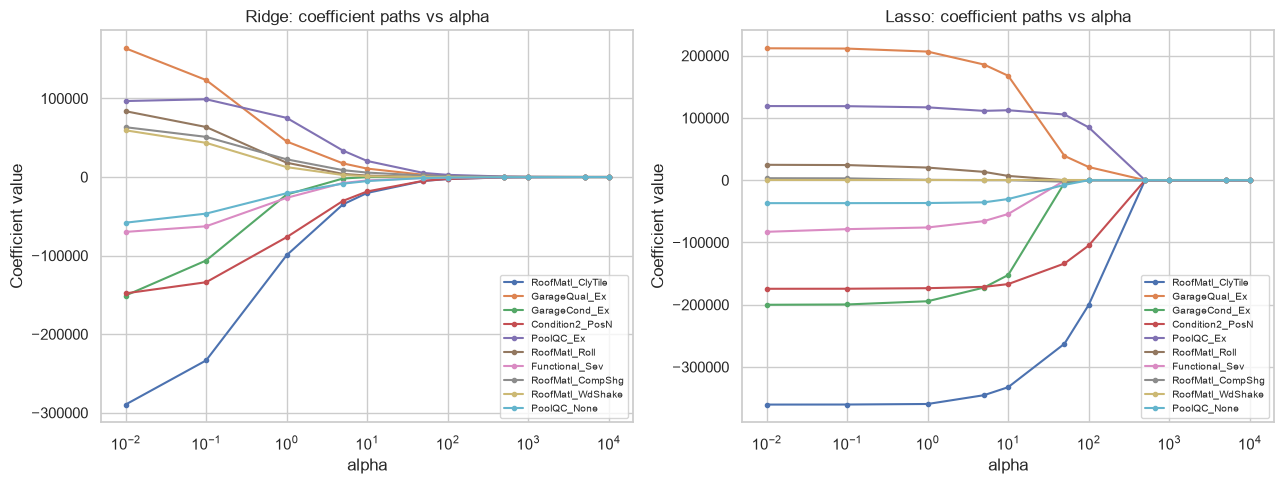

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))


ridge_coef_paths = np.array([ridge_models[a].coef_ for a in ridge_alphas])
for i in np.argsort(-np.abs(lr.coef_))[:10]:
    axes[0].plot(ridge_alphas, ridge_coef_paths[:, i], marker='o', markersize=3, label=feature_names[i])
axes[0].set_xscale('log')
axes[0].set_xlabel('alpha')
axes[0].set_ylabel('Coefficient value')
axes[0].set_title('Ridge: coefficient paths vs alpha')
axes[0].legend(fontsize=7, loc='best')

lasso_coef_paths = np.array([lasso_models[a].coef_ for a in lasso_alphas])
for i in np.argsort(-np.abs(lr.coef_))[:10]:
    axes[1].plot(lasso_alphas, lasso_coef_paths[:, i], marker='o', markersize=3, label=feature_names[i])
axes[1].set_xscale('log')
axes[1].set_xlabel('alpha')
axes[1].set_ylabel('Coefficient value')
axes[1].set_title('Lasso: coefficient paths vs alpha')
axes[1].legend(fontsize=7, loc='best')

plt.tight_layout()
plt.show()


## 14. Analysis of overfitting / underfitting features

In [35]:
gap_table = pd.DataFrame({
    'Linear Regression': {
        'R2_train': lr_train_metrics['R2'], 'R2_val': lr_val_metrics['R2'],
        'gap_R2': lr_train_metrics['R2'] - lr_val_metrics['R2'],
        'RMSE_train': lr_train_metrics['RMSE'], 'RMSE_val': lr_val_metrics['RMSE'],
    },
    f'Ridge (alpha={best_ridge_alpha})': {
        'R2_train': ridge_train_metrics['R2'], 'R2_val': ridge_val_best_metrics['R2'],
        'gap_R2': ridge_train_metrics['R2'] - ridge_val_best_metrics['R2'],
        'RMSE_train': ridge_train_metrics['RMSE'], 'RMSE_val': ridge_val_best_metrics['RMSE'],
    },
    f'Lasso (alpha={best_lasso_alpha})': {
        'R2_train': lasso_train_metrics['R2'], 'R2_val': lasso_val_best_metrics['R2'],
        'gap_R2': lasso_train_metrics['R2'] - lasso_val_best_metrics['R2'],
        'RMSE_train': lasso_train_metrics['RMSE'], 'RMSE_val': lasso_val_best_metrics['RMSE'],
    },
}).T

gap_table

,R2_train,R2_val,gap_R2,RMSE_train,RMSE_val
Linear Regression,0.943527,0.863453,0.080074,18340.594103,28595.499901
Ridge (alpha=10.0),0.911099,0.886858,0.024241,23011.564539,26029.614299
Lasso (alpha=100.0),0.924538,0.894256,0.030282,21201.021872,25164.236359


## 15. Justification for choosing the most suitable model

In [36]:
print("Final comparison (validation set, selected alpha):")
final_compare = pd.DataFrame({
    'Linear Regression': lr_val_metrics,
    f'Ridge (alpha={best_ridge_alpha})': ridge_val_best_metrics,
    f'Lasso (alpha={best_lasso_alpha})': lasso_val_best_metrics,
}).T
display(final_compare)

print(f"\nModel selected based on validation results: {best_name}")
print(f"Result on the independent test set:")
display(pd.Series(final_test_metrics).to_frame('test'))

Final comparison (validation set, selected alpha):


,MAE,MSE,RMSE,R2
Linear Regression,18864.458575,8.177026e+08,28595.499901,0.863453
Ridge (alpha=10.0),16812.617320,6.775408e+08,26029.614299,0.886858
Lasso (alpha=100.0),16230.803965,6.332388e+08,25164.236359,0.894256



Model selected based on validation results: Lasso (alpha=100.0)
Result on the independent test set:


,test
MAE,1.729601e+04
MSE,8.102403e+08
RMSE,2.846472e+04
R2,8.943669e-01
